# Setup

In [ ]:
import gdown
import os
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

folder_url = "https://drive.google.com/drive/folders/1uXVKQPekVddPltkFoB0jXKNFpXjoBc6K"
gdown.download_folder(
    folder_url,
    output="olist_data",
    quiet=False
)
customers = pd.read_csv("olist_data/olist_customers_dataset.csv")
orders = pd.read_csv("olist_data/olist_orders_dataset.csv")
order_items = pd.read_csv("olist_data/olist_order_items_dataset.csv")
payments = pd.read_csv("olist_data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_data/olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_data/olist_products_dataset.csv")
sellers = pd.read_csv("olist_data/olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_data/olist_geolocation_dataset.csv")
categories = pd.read_csv("olist_data/product_category_name_translation.csv")

Retrieving folder contents


Processing file 1nt0wZi1-8iAlnRQdFxksrBxpVVs7yA15 cancellations_table.csv
Processing file 131dMK5eyJKgxB6EF7wb1lMLbnvDIfwYf olist_customers_dataset.csv
Processing file 1jm1aqNlSxTicqL72IxU8ibrS8snKtfDu olist_geolocation_dataset.csv
Processing file 11gLQ3KrJKYZw5ls_lQHtcFIn9VGE7sZ8 olist_order_items_dataset.csv
Processing file 1arOS6VW3L01PVJ1Sx1bdkAKtM_6pMfrV olist_order_payments_dataset.csv
Processing file 1ZTdQObb78QuyvLF7oaACjo39WD-WYqzY olist_order_reviews_dataset.csv
Processing file 1HO_LvT4h-ZYkqtR05gvsvMov4Opoc_p9 olist_orders_dataset.csv
Processing file 10k6y1FF6g1DFKG2SiczBmQaBo4AmlTU2 olist_products_dataset.csv
Processing file 1uaAw540fNfTdoJ5Z8fJp20-zWXQCx14Z olist_sellers_dataset.csv
Processing file 15VPmwnWEyhpeHxLWRv1Dn3Gy1m9FGpev product_category_name_translation.csv
Processing file 1TEfbxAfRwOjQJxLkzR95Zju7I6KYymBM refunds_table.csv
Processing file 1Ax6tt2E-OHfbdr20jMWfuPXMPoZ1sN_M returns_table.csv
Processing file 1UFy5cm68-_wNVcWSsLW0o9mb5JW1E3f6 reviews_dedup.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1nt0wZi1-8iAlnRQdFxksrBxpVVs7yA15
To: /content/olist_data/cancellations_table.csv
100%|██████████| 193k/193k [00:00<00:00, 17.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=131dMK5eyJKgxB6EF7wb1lMLbnvDIfwYf
To: /content/olist_data/olist_customers_dataset.csv
100%|██████████| 9.03M/9.03M [00:00<00:00, 28.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jm1aqNlSxTicqL72IxU8ibrS8snKtfDu
To: /content/olist_data/olist_geolocation_dataset.csv
100%|██████████| 61.3M/61.3M [00:00<00:00, 65.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=11gLQ3KrJKYZw5ls_lQHtcFIn9VGE7sZ8
To: /content/olist_data/olist_order_items_dataset.csv
100%|██████████| 15.4M/15.4M [00:00<00:00, 39.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1arOS6VW3L01PVJ1Sx1bdkAKtM_6pMfrV
To: /content/olist_data/olist_order_payments_da

# Return Candidate Dataset

In [ ]:
reviews_dedup = (
    reviews
    .sort_values(
        "review_creation_date"
    )
    .drop_duplicates(
        subset="order_id",
        keep="last"
    )
)

print("Original review rows:")
print(len(reviews))

print("\nDeduplicated review rows:")
print(len(reviews_dedup))

print("\nDuplicate order_ids remaining:")
print(
    reviews_dedup["order_id"]
    .duplicated()
    .sum()
)

Original review rows:
99224

Deduplicated review rows:
98673

Duplicate order_ids remaining:
0



BUILDING WORKING DATAFRAME

order_items rows: 112650
after orders merge: 112650
after customers merge: 112650
delivered only: 110197
after reviews_dedup merge: 110197
after products merge: 110197

customer_unique_id present:
True

Missing customer_unique_id values:
0

DERIVED FEATURES

Working dataframe shape:
(110197, 18)

CALCULATING RETURN PROBABILITY

RETURN PROBABILITY DISTRIBUTION

Describe:
count    110197.000000
mean          0.113930
std           0.146926
min           0.010000
25%           0.010000
50%           0.050000
75%           0.120000
max           0.760000
Name: return_probability, dtype: float64

Quantiles:
0.50    0.05
0.75    0.12
0.90    0.41
0.95    0.48
0.99    0.58
Name: return_probability, dtype: float64


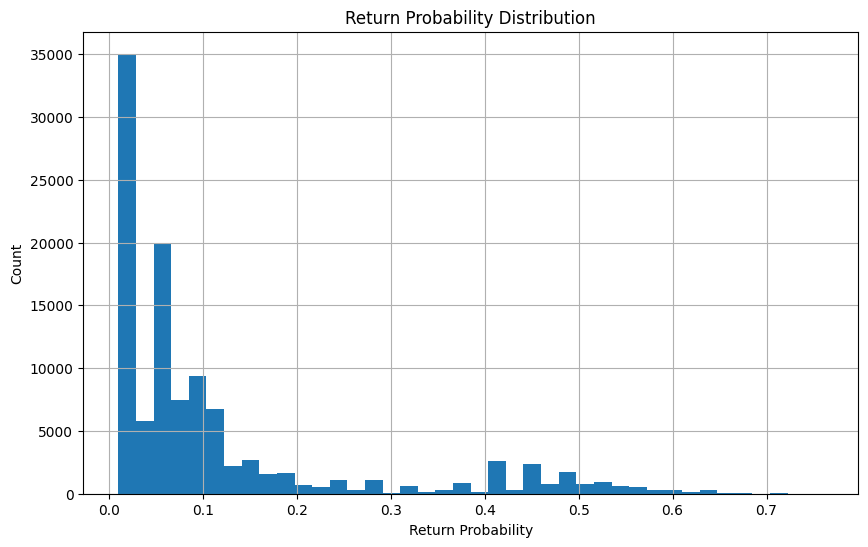


GENERATING RETURNS

Overall Return Rate:
11.32 %

Number of Returned Items:
12474

Returned Item Review Score Distribution:
review_score
1.0    0.482948
2.0    0.086472
3.0    0.107483
4.0    0.119040
5.0    0.204057
Name: proportion, dtype: float64

Average Probability of Returned Items:
0.3051499118165785

Top Returned Probability Quantiles:
0.25    0.11
0.50    0.35
0.75    0.48
0.90    0.54
0.95    0.59
Name: return_probability, dtype: float64

CHECKPOINT COMPLETE

Bring back:

1. return_probability describe()
2. return_probability quantiles
3. overall return rate
4. returned review score distribution

before moving to return reasons,
refunds and cancellations.



In [ ]:


# ============================================================
# LOAD DATA
# ============================================================

customers = pd.read_csv("olist_data/olist_customers_dataset.csv")
orders = pd.read_csv("olist_data/olist_orders_dataset.csv")
order_items = pd.read_csv("olist_data/olist_order_items_dataset.csv")
payments = pd.read_csv("olist_data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_data/olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_data/olist_products_dataset.csv")
sellers = pd.read_csv("olist_data/olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_data/olist_geolocation_dataset.csv")
categories = pd.read_csv("olist_data/product_category_name_translation.csv")

# ============================================================
# CONVERT DATE COLUMNS
# ============================================================

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

# ============================================================
# STEP 1
# BUILD WORKING DATAFRAME
# ONE ROW = ONE ORDER ITEM
# ============================================================

print("\n" + "=" * 80)
print("BUILDING WORKING DATAFRAME")
print("=" * 80)

print(f"\norder_items rows: {len(order_items)}")

# ------------------------------------------------------------
# ORDERS
# ------------------------------------------------------------

df = order_items.merge(
    orders[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ],
    on="order_id",
    how="left"
)

print(f"after orders merge: {len(df)}")

# ------------------------------------------------------------
# CUSTOMERS
# ------------------------------------------------------------

df = df.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id"
        ]
    ],
    on="customer_id",
    how="left"
)

print(f"after customers merge: {len(df)}")

# ------------------------------------------------------------
# KEEP ONLY DELIVERED ORDERS
# ------------------------------------------------------------

df = df[
    df["order_status"] == "delivered"
].copy()

print(f"delivered only: {len(df)}")

# ------------------------------------------------------------
# REVIEWS
# ------------------------------------------------------------

df = df.merge(
    reviews_dedup[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="left"
)

print(f"after reviews_dedup merge: {len(df)}")

# ------------------------------------------------------------
# PRODUCTS
# ------------------------------------------------------------

df = df.merge(
    products[
        [
            "product_id",
            "product_category_name"
        ]
    ],
    on="product_id",
    how="left"
)

print(f"after products merge: {len(df)}")

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("\ncustomer_unique_id present:")
print("customer_unique_id" in df.columns)

print("\nMissing customer_unique_id values:")
print(df["customer_unique_id"].isna().sum())

# ============================================================
# STEP 2
# DERIVED FEATURES
# ============================================================

print("\n" + "=" * 80)
print("DERIVED FEATURES")
print("=" * 80)

# ------------------------------------------------------------
# DELIVERY DELAY
# ------------------------------------------------------------

df["delay_days"] = (
    df["order_delivered_customer_date"]
    -
    df["order_estimated_delivery_date"]
).dt.days

# ------------------------------------------------------------
# SELLER QUALITY
# ------------------------------------------------------------

seller_reviews = (
    order_items[
        [
            "seller_id",
            "order_id"
        ]
    ]
    .merge(
        reviews_dedup[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

seller_quality = (
    seller_reviews
    .groupby("seller_id")
    .agg(
        avg_review_score=(
            "review_score",
            "mean"
        ),
        review_count=(
            "review_score",
            "count"
        )
    )
    .reset_index()
)

platform_avg_seller_score = (
    seller_quality["avg_review_score"]
    .mean()
)

seller_quality["seller_quality_score"] = np.where(
    seller_quality["review_count"] >= 10,
    seller_quality["avg_review_score"],
    platform_avg_seller_score
)

df = df.merge(
    seller_quality[
        [
            "seller_id",
            "seller_quality_score",
            "review_count"
        ]
    ],
    on="seller_id",
    how="left"
)

# ------------------------------------------------------------
# CATEGORY AVG REVIEW
# ------------------------------------------------------------

category_reviews = (
    order_items
    .merge(
        reviews_dedup[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
)

category_avg = (
    category_reviews
    .groupby("product_category_name")
    .agg(
        category_avg_review=(
            "review_score",
            "mean"
        )
    )
    .reset_index()
)

df = df.merge(
    category_avg,
    on="product_category_name",
    how="left"
)

print("\nWorking dataframe shape:")
print(df.shape)

# ============================================================
# STEP 3
# RETURN PROBABILITY
# ============================================================

print("\n" + "=" * 80)
print("CALCULATING RETURN PROBABILITY")
print("=" * 80)

df["return_probability"] = 0.08

# ------------------------------------------------------------
# REVIEW SCORE
# ------------------------------------------------------------

df.loc[
    df["review_score"] == 1,
    "return_probability"
] += 0.35

df.loc[
    df["review_score"] == 2,
    "return_probability"
] += 0.18

df.loc[
    df["review_score"] == 3,
    "return_probability"
] += 0.05

df.loc[
    df["review_score"] == 4,
    "return_probability"
] -= 0.02

df.loc[
    df["review_score"] == 5,
    "return_probability"
] -= 0.05

# ------------------------------------------------------------
# DELIVERY DELAY
# ------------------------------------------------------------

df.loc[
    df["delay_days"] > 14,
    "return_probability"
] += 0.15

df.loc[
    (
        df["delay_days"] > 7
    )
    &
    (
        df["delay_days"] <= 14
    ),
    "return_probability"
] += 0.10

df.loc[
    (
        df["delay_days"] > 0
    )
    &
    (
        df["delay_days"] <= 7
    ),
    "return_probability"
] += 0.05

# ------------------------------------------------------------
# SELLER QUALITY
# ------------------------------------------------------------

df.loc[
    df["seller_quality_score"] < 2.5,
    "return_probability"
] += 0.10

df.loc[
    (
        df["seller_quality_score"] >= 2.5
    )
    &
    (
        df["seller_quality_score"] < 3.5
    ),
    "return_probability"
] += 0.05

df.loc[
    (
        df["seller_quality_score"] >= 3.5
    )
    &
    (
        df["seller_quality_score"] < 4.0
    ),
    "return_probability"
] += 0.02

df.loc[
    df["seller_quality_score"] > 4.0,
    "return_probability"
] -= 0.02

# ------------------------------------------------------------
# PRICE
# ------------------------------------------------------------

df.loc[
    df["price"] > 280,
    "return_probability"
] += 0.08

df.loc[
    (
        df["price"] >= 135
    )
    &
    (
        df["price"] <= 280
    ),
    "return_probability"
] += 0.04

df.loc[
    df["price"] < 40,
    "return_probability"
] -= 0.03

# ------------------------------------------------------------
# CATEGORY
# ------------------------------------------------------------

df.loc[
    df["category_avg_review"] < 3.9,
    "return_probability"
] += 0.04

df.loc[
    df["category_avg_review"] > 4.2,
    "return_probability"
] -= 0.03

# ------------------------------------------------------------
# CLIP
# ------------------------------------------------------------

df["return_probability"] = (
    df["return_probability"]
    .clip(
        lower=0.01,
        upper=0.95
    )
)

# ============================================================
# STEP 4
# INSPECT DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("RETURN PROBABILITY DISTRIBUTION")
print("=" * 80)

print("\nDescribe:")
print(
    df["return_probability"]
    .describe()
)

print("\nQuantiles:")
print(
    df["return_probability"]
    .quantile(
        [
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

plt.figure(figsize=(10,6))
df["return_probability"].hist(
    bins=40
)
plt.title(
    "Return Probability Distribution"
)
plt.xlabel(
    "Return Probability"
)
plt.ylabel(
    "Count"
)
plt.show()

# ============================================================
# STEP 5
# GENERATE RETURNS
# ============================================================

print("\n" + "=" * 80)
print("GENERATING RETURNS")
print("=" * 80)

np.random.seed(42)

df["is_return"] = (
    np.random.random(
        len(df)
    )
    <
    df["return_probability"]
)

return_rate = (
    df["is_return"]
    .mean()
)

print("\nOverall Return Rate:")
print(
    round(
        return_rate * 100,
        2
    ),
    "%"
)

returns_df = df[
    df["is_return"]
].copy()

print("\nNumber of Returned Items:")
print(len(returns_df))

# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

print("\nReturned Item Review Score Distribution:")
print(
    returns_df["review_score"]
    .value_counts(
        normalize=True
    )
    .sort_index()
)

print("\nAverage Probability of Returned Items:")
print(
    returns_df["return_probability"]
    .mean()
)

print("\nTop Returned Probability Quantiles:")
print(
    returns_df["return_probability"]
    .quantile(
        [
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)





In [ ]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [ ]:
reviews["order_id"].nunique()

98673

# Returns Table Generation

In [ ]:
# ==========================================================
# RETURN REASON ASSIGNMENT & RETURNS TABLE CREATION
# ==========================================================

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# 1. RANDOM SEED
# ----------------------------------------------------------

np.random.seed(42)

# ----------------------------------------------------------
# 2. RETURN REASON ASSIGNMENT FUNCTION
# ----------------------------------------------------------

def assign_return_reason(row):

    review_score = row["review_score"]
    seller_quality = row["seller_quality_score"]
    delay_days = row["delay_days"]

    # ------------------------------
    # Missing review
    # ------------------------------
    if pd.isna(review_score):

        reasons = [
            "Changed Mind",
            "Quality Below Expectations",
            "Not as Described",
            "Wrong Item Received",
            "Defective/Damaged"
        ]

        weights = [50, 20, 15, 10, 5]

    # ------------------------------
    # Review score 1-2
    # ------------------------------
    elif review_score <= 2:

        if seller_quality >= 2.5:

            reasons = [
                "Defective/Damaged",
                "Not as Described",
                "Quality Below Expectations",
                "Late Delivery",
                "Wrong Item Received"
            ]

            weights = [35, 30, 20, 10, 5]

        else:

            reasons = [
                "Defective/Damaged",
                "Not as Described",
                "Quality Below Expectations",
                "Late Delivery",
                "Wrong Item Received"
            ]

            weights = [35, 25, 15, 10, 15]

    # ------------------------------
    # Review score 3-4
    # ------------------------------
    elif review_score in [3, 4]:

        reasons = [
            "Defective/Damaged",
            "Not as Described",
            "Quality Below Expectations",
            "Changed Mind",
            "Late Delivery",
            "Wrong Item Received"
        ]

        weights = [20, 15, 20, 25, 10, 10]

    # ------------------------------
    # Review score 5
    # ------------------------------
    else:

        reasons = [
            "Changed Mind",
            "Wrong Item Received"
        ]

        weights = [85, 15]

    # ------------------------------------------------------
    # Remove Late Delivery if not eligible
    # ------------------------------------------------------

    if "Late Delivery" in reasons and (pd.isna(delay_days) or delay_days <= 0):

        idx = reasons.index("Late Delivery")

        reasons.pop(idx)
        removed_weight = weights.pop(idx)

        remaining_total = sum(weights)

        weights = [
            w + (w / remaining_total) * removed_weight
            for w in weights
        ]

    # Normalize
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()

    return np.random.choice(reasons, p=weights)


# ----------------------------------------------------------
# 3. ASSIGN RETURN REASONS
# ----------------------------------------------------------

returns_df["return_reason"] = returns_df.apply(
    assign_return_reason,
    axis=1
)

# ----------------------------------------------------------
# 4. REASON DISTRIBUTION
# ----------------------------------------------------------

print("=" * 60)
print("RETURN REASON COUNTS")
print("=" * 60)

reason_counts = returns_df["return_reason"].value_counts()

print(reason_counts)

print("\n")

print("=" * 60)
print("RETURN REASON PERCENTAGES")
print("=" * 60)

reason_percentages = (
    returns_df["return_reason"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(reason_percentages)

# ----------------------------------------------------------
# 5. TARGET VS ACTUAL DISTRIBUTION COMPARISON
# ----------------------------------------------------------

print("\n")
print("=" * 60)
print("TARGET VS ACTUAL DISTRIBUTION")
print("=" * 60)

# Approximate global target distribution
# Derived from weighted assignment logic

target_distribution = {
    "Defective/Damaged": 25.0,
    "Not as Described": 18.0,
    "Quality Below Expectations": 18.0,
    "Changed Mind": 25.0,
    "Wrong Item Received": 10.0,
    "Late Delivery": 4.0
}

comparison_df = pd.DataFrame({
    "target_pct": pd.Series(target_distribution)
})

comparison_df["actual_pct"] = (
    reason_percentages
    .reindex(comparison_df.index)
    .fillna(0)
)

comparison_df["difference"] = (
    comparison_df["actual_pct"]
    - comparison_df["target_pct"]
).round(2)

print(comparison_df)

# ----------------------------------------------------------
# 6. GENERATE SYNTHETIC RETURN DATE
# ----------------------------------------------------------

print("\n")
print("=" * 60)
print("GENERATING RETURN DATES")
print("=" * 60)

# Locate delivery date column automatically

possible_delivery_cols = [
    "order_delivered_customer_date",
    "delivered_date",
    "delivery_date"
]

delivery_col = None

for col in possible_delivery_cols:
    if col in returns_df.columns:
        delivery_col = col
        break

if delivery_col is None:
    raise ValueError(
        "No delivery date column found. "
        "Expected one of: "
        f"{possible_delivery_cols}"
    )

returns_df[delivery_col] = pd.to_datetime(
    returns_df[delivery_col]
)

return_lag_days = np.random.randint(
    1,
    31,
    size=len(returns_df)
)

returns_df["return_date"] = (
    returns_df[delivery_col]
    + pd.to_timedelta(return_lag_days, unit="D")
)

# ----------------------------------------------------------
# 7. CREATE RETURNS TABLE
# ----------------------------------------------------------

print("\n")
print("=" * 60)
print("CREATING RETURNS TABLE")
print("=" * 60)

returns_table = returns_df.copy()

returns_table["return_id"] = [
    f"RET_{i:07d}"
    for i in range(1, len(returns_table) + 1)
]

returns_table["item_price"] = returns_table["price"]

returns_table = returns_table[
    [
        "return_id",
        "order_id",
        "order_item_id",
        "customer_unique_id",
        "product_id",
        "seller_id",
        "return_date",
        "return_reason",
        "item_price"
    ]
]

# ----------------------------------------------------------
# 8. RETURNS TABLE VALIDATION
# ----------------------------------------------------------

print("\n")
print("=" * 60)
print("RETURNS TABLE SHAPE")
print("=" * 60)

print(returns_table.shape)

print("\n")

print("=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)

print(returns_table.head(10))

print("\n")

print("=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)

print(returns_table.isnull().sum())

# ----------------------------------------------------------
# RETURNS TABLE CREATED
# ----------------------------------------------------------

RETURN REASON COUNTS
return_reason
Defective/Damaged             3331
Changed Mind                  2965
Not as Described              2688
Quality Below Expectations    2153
Wrong Item Received           1090
Late Delivery                  247
Name: count, dtype: int64


RETURN REASON PERCENTAGES
return_reason
Defective/Damaged             26.70
Changed Mind                  23.77
Not as Described              21.55
Quality Below Expectations    17.26
Wrong Item Received            8.74
Late Delivery                  1.98
Name: proportion, dtype: float64


TARGET VS ACTUAL DISTRIBUTION
                            target_pct  actual_pct  difference
Defective/Damaged                 25.0       26.70        1.70
Not as Described                  18.0       21.55        3.55
Quality Below Expectations        18.0       17.26       -0.74
Changed Mind                      25.0       23.77       -1.23
Wrong Item Received               10.0        8.74       -1.26
Late Delivery               

In [ ]:
print("customer_unique_id" in returns_df.columns)

True


In [ ]:
print(returns_table.columns.tolist())

['return_id', 'order_id', 'order_item_id', 'customer_unique_id', 'product_id', 'seller_id', 'return_date', 'return_reason', 'item_price']


In [ ]:
print(
    returns_table["customer_unique_id"]
    .isna()
    .sum()
)

0


# Refunds Table Generation

In [ ]:

# ============================================================
# RANDOM SEED
# ============================================================

np.random.seed(42)

# ============================================================
# CREATE WORKING COPY
# ============================================================

refunds_table = returns_table.copy()

# ============================================================
# REFUND LOGIC FUNCTION
# ============================================================

def generate_refund(row):

    reason = row["return_reason"]
    item_price = row["item_price"]

    # --------------------------------------------------------
    # DEFECTIVE / DAMAGED
    # --------------------------------------------------------

    if reason == "Defective/Damaged":

        if np.random.random() < 0.90:
            refund_type = "Full"
            refund_amount = item_price

        else:
            refund_type = "Partial"
            refund_amount = item_price * np.random.uniform(
                0.70,
                0.90
            )

    # --------------------------------------------------------
    # WRONG ITEM RECEIVED
    # --------------------------------------------------------

    elif reason == "Wrong Item Received":

        refund_type = "Full"
        refund_amount = item_price

    # --------------------------------------------------------
    # NOT AS DESCRIBED
    # --------------------------------------------------------

    elif reason == "Not as Described":

        if np.random.random() < 0.70:
            refund_type = "Full"
            refund_amount = item_price

        else:
            refund_type = "Partial"
            refund_amount = item_price * np.random.uniform(
                0.70,
                0.95
            )

    # --------------------------------------------------------
    # QUALITY BELOW EXPECTATIONS
    # --------------------------------------------------------

    elif reason == "Quality Below Expectations":

        if np.random.random() < 0.50:
            refund_type = "Full"
            refund_amount = item_price

        else:
            refund_type = "Partial"
            refund_amount = item_price * np.random.uniform(
                0.60,
                0.90
            )

    # --------------------------------------------------------
    # CHANGED MIND
    # --------------------------------------------------------

    elif reason == "Changed Mind":

        if np.random.random() < 0.20:
            refund_type = "Full"
            refund_amount = item_price

        else:
            refund_type = "Partial"
            refund_amount = item_price * np.random.uniform(
                0.50,
                0.85
            )

    # --------------------------------------------------------
    # LATE DELIVERY
    # --------------------------------------------------------

    elif reason == "Late Delivery":

        if np.random.random() < 0.10:
            refund_type = "Full"
            refund_amount = item_price

        else:
            refund_type = "Partial"
            refund_amount = item_price * np.random.uniform(
                0.60,
                0.90
            )

    # --------------------------------------------------------
    # FALLBACK
    # --------------------------------------------------------

    else:

        refund_type = "Partial"
        refund_amount = item_price * 0.80

    return pd.Series(
        [
            refund_type,
            round(refund_amount, 2)
        ]
    )

# ============================================================
# GENERATE REFUND TYPE + REFUND AMOUNT
# ============================================================

print("\n" + "=" * 80)
print("GENERATING REFUND TYPES AND AMOUNTS")
print("=" * 80)

refunds_table[
    [
        "refund_type",
        "refund_amount"
    ]
] = refunds_table.apply(
    generate_refund,
    axis=1
)

# ============================================================
# REFUND DATE
# ============================================================

print("\n" + "=" * 80)
print("GENERATING REFUND DATES")
print("=" * 80)

refund_lag_days = np.random.randint(
    1,
    11,
    size=len(refunds_table)
)

refunds_table["refund_date"] = (
    pd.to_datetime(
        refunds_table["return_date"]
    )
    +
    pd.to_timedelta(
        refund_lag_days,
        unit="D"
    )
)

# ============================================================
# REFUND STATUS
# ============================================================

print("\n" + "=" * 80)
print("GENERATING REFUND STATUS")
print("=" * 80)

refunds_table["refund_status"] = np.where(
    np.random.random(
        len(refunds_table)
    ) < 0.95,
    "Processed",
    "Pending"
)

# ============================================================
# REFUND ID
# ============================================================

refunds_table["refund_id"] = [
    f"REF_{i:07d}"
    for i in range(
        1,
        len(refunds_table) + 1
    )
]

# ============================================================
# COPY RETURN REASON AS REFUND REASON
# ============================================================

refunds_table["refund_reason"] = (
    refunds_table["return_reason"]
)

# ============================================================
# FINAL COLUMN ORDER
# ============================================================

refunds_table = refunds_table[
    [
        "refund_id",
        "return_id",
        "order_id",
        "customer_unique_id",
        "seller_id",
        "refund_date",
        "refund_reason",
        "refund_type",
        "refund_status",
        "item_price",
        "refund_amount"
    ]
]
# ============================================================
# REFUND TYPE DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("REFUND TYPE DISTRIBUTION")
print("=" * 80)

print(
    refunds_table["refund_type"]
    .value_counts()
)

print("\nPercentages:")

print(
    (
        refunds_table["refund_type"]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

# ============================================================
# REFUND STATUS DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("REFUND STATUS DISTRIBUTION")
print("=" * 80)

print(
    refunds_table["refund_status"]
    .value_counts()
)

print("\nPercentages:")

print(
    (
        refunds_table["refund_status"]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

# ============================================================
# REFUND AMOUNT SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("REFUND AMOUNT SUMMARY")
print("=" * 80)

print(
    refunds_table["refund_amount"]
    .describe()
)

# ============================================================
# TOTAL REFUND VALUE
# ============================================================

print("\n" + "=" * 80)
print("TOTAL REFUND VALUE")
print("=" * 80)

print(
    round(
        refunds_table["refund_amount"]
        .sum(),
        2
    )
)

# ============================================================
# REFUND RATIO
# ============================================================

refunds_table["refund_ratio"] = (
    refunds_table["refund_amount"]
    /
    refunds_table["item_price"]
)

print("\n" + "=" * 80)
print("REFUND RATIO SUMMARY")
print("=" * 80)

print(
    refunds_table["refund_ratio"]
    .describe()
)

# ============================================================
# TABLE SHAPE
# ============================================================

print("\n" + "=" * 80)
print("REFUNDS TABLE SHAPE")
print("=" * 80)

print(
    refunds_table.shape
)

# ============================================================
# FIRST 10 ROWS
# ============================================================

print("\n" + "=" * 80)
print("FIRST 10 ROWS")
print("=" * 80)

print(
    refunds_table.head(10)
)

# ============================================================
# MISSING VALUES
# ============================================================

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)

print(
    refunds_table.isnull()
    .sum()
)

# ============================================================
# CHECKPOINT
# ============================================================

print("""
Generated:
- refund_id
- refund_date
- refund_reason
- refund_type
- refund_status
- refund_amount
- refund_ratio

Output:
refunds_table
""")


GENERATING REFUND TYPES AND AMOUNTS

GENERATING REFUND DATES

GENERATING REFUND STATUS

REFUND TYPE DISTRIBUTION
refund_type
Full       7693
Partial    4781
Name: count, dtype: int64

Percentages:
refund_type
Full       61.67
Partial    38.33
Name: proportion, dtype: float64

REFUND STATUS DISTRIBUTION
refund_status
Processed    11872
Pending        602
Name: count, dtype: int64

Percentages:
refund_status
Processed    95.17
Pending       4.83
Name: proportion, dtype: float64

REFUND AMOUNT SUMMARY
count    12474.000000
mean       131.878947
std        194.427820
min          1.100000
25%         42.365000
50%         79.080000
75%        145.000000
max       3930.000000
Name: refund_amount, dtype: float64

TOTAL REFUND VALUE
1645057.99

REFUND RATIO SUMMARY
count    12474.000000
mean         0.895382
std          0.148466
min          0.500025
25%          0.783525
50%          1.000000
75%          1.000000
max          1.000000
Name: refund_ratio, dtype: float64

REFUNDS TABLE SHAP

In [ ]:
print("seller_id" in returns_table.columns)

True


In [ ]:
print("seller_id" in refunds_table.columns)


True


In [ ]:
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


# Cancellations Table Generation

In [ ]:
# ============================================================
# CANCELLATIONS TABLE GENERATION
# ============================================================

# ============================================================
# RANDOM SEED
# ============================================================

np.random.seed(42)

# ============================================================
# IDENTIFY CANCELLED ORDERS
# ============================================================

print("\n" + "=" * 80)
print("IDENTIFYING CANCELLED ORDERS")
print("=" * 80)

cancelled_orders = orders[
    orders["order_status"].isin(
        [
            "canceled",
            "unavailable"
        ]
    )
].copy()

print("\nCancelled / Unavailable Orders:")
print(len(cancelled_orders))

print("\nStatus Distribution:")
print(
    cancelled_orders["order_status"]
    .value_counts()
)

# ============================================================
# CUSTOMER INFORMATION
# ============================================================

cancelled_orders = cancelled_orders.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id"
        ]
    ],
    on="customer_id",
    how="left"
)

# ============================================================
# ORDER VALUE
# ============================================================

order_values = (
    order_items
    .groupby("order_id")
    .agg(
        order_value=(
            "price",
            "sum"
        )
    )
    .reset_index()
)

cancelled_orders = cancelled_orders.merge(
    order_values,
    on="order_id",
    how="left"
)

# ============================================================
# PRIMARY SELLER
# ============================================================
# Assign seller with highest order value
# (needed later for seller risk features)

seller_value = (
    order_items
    .groupby(
        [
            "order_id",
            "seller_id"
        ]
    )
    .agg(
        seller_order_value=(
            "price",
            "sum"
        )
    )
    .reset_index()
)

primary_seller = (
    seller_value
    .sort_values(
        "seller_order_value",
        ascending=False
    )
    .drop_duplicates(
        subset="order_id"
    )
    [
        [
            "order_id",
            "seller_id"
        ]
    ]
)

cancelled_orders = cancelled_orders.merge(
    primary_seller,
    on="order_id",
    how="left"
)

# ============================================================
# CANCELLATION REASON ASSIGNMENT
# ============================================================

print("\n" + "=" * 80)
print("GENERATING CANCELLATION REASONS")
print("=" * 80)

def assign_cancellation_reason(row):

    status = row["order_status"]

    # --------------------------------------------------------
    # CANCELED ORDERS
    # --------------------------------------------------------

    if status == "canceled":

        reasons = [
            "Customer Requested",
            "Payment Failure",
            "Seller Unable Fulfill",
            "Logistics Issue"
        ]

        weights = [
            40,
            25,
            20,
            15
        ]

    # --------------------------------------------------------
    # UNAVAILABLE ORDERS
    # --------------------------------------------------------

    else:

        reasons = [
            "Out of Stock",
            "Seller Unable Fulfill",
            "Logistics Issue"
        ]

        weights = [
            50,
            30,
            20
        ]

    weights = np.array(weights)
    weights = weights / weights.sum()

    return np.random.choice(
        reasons,
        p=weights
    )

cancelled_orders["cancellation_reason"] = (
    cancelled_orders.apply(
        assign_cancellation_reason,
        axis=1
    )
)

# ============================================================
# CANCELLATION TYPE
# ============================================================

reason_type_map = {
    "Customer Requested": "Customer Issue",
    "Payment Failure": "Payment Issue",
    "Out of Stock": "Seller Issue",
    "Seller Unable Fulfill": "Seller Issue",
    "Logistics Issue": "Logistics Issue"
}

cancelled_orders["cancellation_type"] = (
    cancelled_orders["cancellation_reason"]
    .map(reason_type_map)
)

# ============================================================
# CANCELLATION DATE
# ============================================================
# Use available order timestamps and add small noise

print("\n" + "=" * 80)
print("GENERATING CANCELLATION DATES")
print("=" * 80)

base_date = (
    cancelled_orders["order_approved_at"]
    .fillna(
        cancelled_orders["order_purchase_timestamp"]
    )
)

lag_days = np.random.randint(
    0,
    8,
    size=len(cancelled_orders)
)

cancelled_orders["cancellation_date"] = (
    pd.to_datetime(base_date)
    +
    pd.to_timedelta(
        lag_days,
        unit="D"
    )
)

# ============================================================
# CANCELLATION ID
# ============================================================

cancelled_orders["cancellation_id"] = [
    f"CAN_{i:07d}"
    for i in range(
        1,
        len(cancelled_orders) + 1
    )
]

# ============================================================
# FINAL TABLE
# ============================================================

cancellations_table = cancelled_orders[
    [
        "cancellation_id",
        "order_id",
        "customer_unique_id",
        "seller_id",
        "cancellation_date",
        "cancellation_reason",
        "cancellation_type",
        "order_value"
    ]
].copy()

# ============================================================
# REASON DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("CANCELLATION REASON DISTRIBUTION")
print("=" * 80)

print(
    cancellations_table[
        "cancellation_reason"
    ].value_counts()
)

print("\nPercentages:")

print(
    (
        cancellations_table[
            "cancellation_reason"
        ]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

# ============================================================
# TYPE DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("CANCELLATION TYPE DISTRIBUTION")
print("=" * 80)

print(
    cancellations_table[
        "cancellation_type"
    ].value_counts()
)

print("\nPercentages:")

print(
    (
        cancellations_table[
            "cancellation_type"
        ]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

# ============================================================
# ORDER VALUE SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("ORDER VALUE SUMMARY")
print("=" * 80)

print(
    cancellations_table[
        "order_value"
    ].describe()
)

# ============================================================
# TOTAL CANCELLED VALUE
# ============================================================

print("\n" + "=" * 80)
print("TOTAL CANCELLED ORDER VALUE")
print("=" * 80)

print(
    round(
        cancellations_table[
            "order_value"
        ].sum(),
        2
    )
)

# ============================================================
# TABLE SHAPE
# ============================================================

print("\n" + "=" * 80)
print("CANCELLATIONS TABLE SHAPE")
print("=" * 80)

print(
    cancellations_table.shape
)

# ============================================================
# FIRST 10 ROWS
# ============================================================

print("\n" + "=" * 80)
print("FIRST 10 ROWS")
print("=" * 80)

print(
    cancellations_table.head(10)
)

# ============================================================
# MISSING VALUES
# ============================================================

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)

print(
    cancellations_table
    .isnull()
    .sum()
)

# ============================================================
# CHECKPOINT
# ============================================================
print("""
Generated:
- cancellation_id
- cancellation_date
- cancellation_reason
- cancellation_type
- order_value

Output:
cancellations_table
""")


IDENTIFYING CANCELLED ORDERS

Cancelled / Unavailable Orders:
1234

Status Distribution:
order_status
canceled       625
unavailable    609
Name: count, dtype: int64

GENERATING CANCELLATION REASONS

GENERATING CANCELLATION DATES

CANCELLATION REASON DISTRIBUTION
cancellation_reason
Out of Stock             300
Seller Unable Fulfill    300
Customer Requested       258
Logistics Issue          229
Payment Failure          147
Name: count, dtype: int64

Percentages:
cancellation_reason
Out of Stock             24.31
Seller Unable Fulfill    24.31
Customer Requested       20.91
Logistics Issue          18.56
Payment Failure          11.91
Name: proportion, dtype: float64

CANCELLATION TYPE DISTRIBUTION
cancellation_type
Seller Issue       600
Customer Issue     258
Logistics Issue    229
Payment Issue      147
Name: count, dtype: int64

Percentages:
cancellation_type
Seller Issue       48.62
Customer Issue     20.91
Logistics Issue    18.56
Payment Issue      11.91
Name: proportion, dtyp

# Data Quality Cleanup

In [ ]:
# ============================================================
# CANCELLATIONS TABLE CLEANUP
# ============================================================

# Fill missing order values
cancellations_table["order_value"] = (
    cancellations_table["order_value"]
    .fillna(0)
)

# Preserve seller information where available
# and explicitly mark unknown sellers

cancellations_table["seller_id"] = (
    cancellations_table["seller_id"]
    .fillna("UNKNOWN_SELLER")
)

# ============================================================
# VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("POST-CLEANUP VALIDATION")
print("=" * 80)

print("\nMissing Values:")

print(
    cancellations_table.isnull().sum()
)

print("\nSeller ID Distribution:")

print(
    cancellations_table["seller_id"]
    .value_counts()
    .head()
)

print("\nOrder Value Summary:")

print(
    cancellations_table["order_value"]
    .describe()
)


POST-CLEANUP VALIDATION

Missing Values:
cancellation_id        0
order_id               0
customer_unique_id     0
seller_id              0
cancellation_date      0
cancellation_reason    0
cancellation_type      0
order_value            0
dtype: int64

Seller ID Distribution:
seller_id
UNKNOWN_SELLER                      767
cc419e0650a3c5ba77189a1882b7556a      9
620c87c171fb2a6dd6e8bb4dec959fc6      8
6560211a19b47992c3666cc44a7e94c0      7
81783131d2a97c8d44d406a4be81b5d9      5
Name: count, dtype: int64

Order Value Summary:
count    1234.000000
mean       78.803047
std       264.381432
min         0.000000
25%         0.000000
50%         0.000000
75%        59.900000
max      4599.900000
Name: order_value, dtype: float64


In [ ]:
cancellations_table.isnull().sum()

,0
cancellation_id,0
order_id,0
customer_unique_id,0
seller_id,0
cancellation_date,0
cancellation_reason,0
cancellation_type,0
order_value,0


# Export Synthetic Tables

In [ ]:
print(refunds_table.columns.tolist())
print(cancellations_table.columns.tolist())
print(returns_table.columns.tolist())

['refund_id', 'return_id', 'order_id', 'customer_unique_id', 'seller_id', 'refund_date', 'refund_reason', 'refund_type', 'refund_status', 'item_price', 'refund_amount', 'refund_ratio']
['cancellation_id', 'order_id', 'customer_unique_id', 'seller_id', 'cancellation_date', 'cancellation_reason', 'cancellation_type', 'order_value']
['return_id', 'order_id', 'order_item_id', 'customer_unique_id', 'product_id', 'seller_id', 'return_date', 'return_reason', 'item_price']


In [ ]:
# ============================================================
# SAVE + DOWNLOAD SYNTHETIC TABLES
# ============================================================

returns_table.to_csv(
    "returns_table.csv",
    index=False
)

refunds_table.to_csv(
    "refunds_table.csv",
    index=False
)

cancellations_table.to_csv(
    "cancellations_table.csv",
    index=False
)

from google.colab import files

files.download("returns_table.csv")
files.download("refunds_table.csv")
files.download("cancellations_table.csv")
reviews_dedup.to_csv(
    "reviews_dedup.csv",
    index=False
)

files.download("reviews_dedup.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>